# CICIDS2017 - Exploratory Data Analysis
**Project:** AI Based Alert Prioritization for Network Intrusion Detection  
**Dataset:** CIC-IDS2017 (MachineLearningCVE CSVs)

## 1. Imports and Setup

In [35]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

## 2. Load Data

In [2]:
data_dir = Path("data/MachineLearningCSV/MachineLearningCVE")
df1 = pd.read_csv(data_dir / "Monday-WorkingHours.pcap_ISCX.csv")
df2 = pd.read_csv(data_dir / "Tuesday-WorkingHours.pcap_ISCX.csv")
df3 = pd.read_csv(data_dir / "Wednesday-workingHours.pcap_ISCX.csv")
df4 = pd.read_csv(data_dir / "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv")
df5 = pd.read_csv(data_dir / "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv")
df6 = pd.read_csv(data_dir / "Friday-WorkingHours-Morning.pcap_ISCX.csv")
df7 = pd.read_csv(data_dir / "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv")
df8 = pd.read_csv(data_dir / "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")


## 3. Basic Structure

In [3]:
# Shapes
print("Dataframe shapes: ")
print(df1.shape)
print(df2.shape)
print(df3.shape)
print(df4.shape)
print(df5.shape)
print(df6.shape)
print(df7.shape)
print(df8.shape)

# Verify that all csv files have the same columns
print("\nVerify Consistent Column Names: ")
print(list(df1.columns) == list(df2.columns) == list(df3.columns) == list(df4.columns) 
      == list(df5.columns) == list(df6.columns) == list(df7.columns) == list(df8.columns))
print("\nData Types")
print(f"df1: {set(df1.dtypes)}")
print(f"df2: {set(df2.dtypes)}")
print(f"df3: {set(df3.dtypes)}")
print(f"df4: {set(df4.dtypes)}")
print(f"df5: {set(df5.dtypes)}")
print(f"df6: {set(df6.dtypes)}")
print(f"df7: {set(df7.dtypes)}")
print(f"df8: {set(df8.dtypes)}")

# Combine into single dataframe
dfs = [df1, df2, df3, df4, df5, df6, df7, df8]
df_complete = pd.concat(dfs)
df_complete.shape
df_complete.columns = df_complete.columns.str.strip()

Dataframe shapes: 
(529918, 79)
(445909, 79)
(692703, 79)
(170366, 79)
(288602, 79)
(191033, 79)
(286467, 79)
(225745, 79)

Verify Consistent Column Names: 
True

Data Types
df1: {dtype('float64'), dtype('int64'), <StringDtype(storage='python', na_value=nan)>}
df2: {dtype('float64'), dtype('int64'), <StringDtype(storage='python', na_value=nan)>}
df3: {dtype('float64'), dtype('int64'), <StringDtype(storage='python', na_value=nan)>}
df4: {dtype('float64'), dtype('int64'), <StringDtype(storage='python', na_value=nan)>}
df5: {dtype('float64'), dtype('int64'), <StringDtype(storage='python', na_value=nan)>}
df6: {dtype('float64'), dtype('int64'), <StringDtype(storage='python', na_value=nan)>}
df7: {dtype('float64'), dtype('int64'), <StringDtype(storage='python', na_value=nan)>}
df8: {dtype('float64'), dtype('int64'), <StringDtype(storage='python', na_value=nan)>}


## 4. Label Distribution

In [4]:
total = df_complete.shape[0]
# for x in df_complete["Label"].value_counts():
#     print(x)
print("Class Counts")
for index, value in df_complete["Label"].value_counts().items():
    print(f"{index}: {round((value/total)*100, 4)}%")


Class Counts
BENIGN: 80.3004%
DoS Hulk: 8.163%
PortScan: 5.6144%
DDoS: 4.5227%
DoS GoldenEye: 0.3636%
FTP-Patator: 0.2804%
SSH-Patator: 0.2083%
DoS slowloris: 0.2048%
DoS Slowhttptest: 0.1943%
Bot: 0.0695%
Web Attack � Brute Force: 0.0532%
Web Attack � XSS: 0.023%
Infiltration: 0.0013%
Web Attack � Sql Injection: 0.0007%
Heartbleed: 0.0004%


## 5. Data Quality

In [5]:
# NaNs
df_complete = df_complete.replace([np.inf, -np.inf], np.nan)
null_counts = df_complete.isnull().sum()
print("Null Counts: ")
print(null_counts[null_counts > 0])

# Drop NaNs
df_complete = df_complete.dropna()

# Duplicate rows
print("\nDuplicate Rows")
print(df_complete.duplicated().sum())

# Drop Duplicates
df_complete = df_complete.drop_duplicates()

df_complete.shape


Null Counts: 
Flow Bytes/s      2867
Flow Packets/s    2867
dtype: int64

Duplicate Rows
307078


(2520798, 79)

In [6]:
# Zero Variance Columns
print("Zero variance columns")
zero_var = df_complete.columns[df_complete.nunique() == 1]
print(zero_var)

# Drop zero variance columns
df_complete = df_complete.drop(columns=zero_var)
df_complete.shape

Zero variance columns
Index(['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk',
       'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk',
       'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate'],
      dtype='str')


(2520798, 71)

## 6. Feature Correlations

In [37]:
# Pearson correlation coefficient
corr_matrix = df_complete.iloc[:, :-1].corr()

In [38]:
# Identify highly correlated features
corr_matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

threshold = 0.85 # Can fine tune threshold if needed
high_corr = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'correlation'})
    .query('abs(correlation) >= @threshold')
    .sort_values('correlation', ascending=False)
    )
print(high_corr)

# Drop highly correlated features, drop one feature per pair
to_drop = set()
for _, row in high_corr.iterrows():
    if row['feature_1'] not in to_drop:
        to_drop.add(row['feature_2'])

print(f"\nFeatures to drop: {len(to_drop)}")
print(to_drop)

df_reduced = df_complete.drop(columns=to_drop)
print(f"\nRemaining features: {df_reduced.shape[1]}")

                   feature_1               feature_2  correlation
194        Total Fwd Packets     Subflow Fwd Packets     1.000000
611   Fwd Packet Length Mean    Avg Fwd Segment Size     1.000000
266   Total Backward Packets     Subflow Bwd Packets     1.000000
2293       Fwd Header Length     Fwd Header Length.1     1.000000
892   Bwd Packet Length Mean    Avg Bwd Segment Size     1.000000
...                      ...                     ...          ...
3980     Subflow Bwd Packets        act_data_pkt_fwd     0.882566
738    Bwd Packet Length Max      Packet Length Mean     0.879047
750    Bwd Packet Length Max     Average Packet Size     0.873955
1609             Fwd IAT Std                Idle Min     0.873841
740    Bwd Packet Length Max  Packet Length Variance     0.851979

[89 rows x 3 columns]

Features to drop: 32
{'SYN Flag Count', 'Fwd Packet Length Mean', 'Fwd IAT Total', 'Total Backward Packets', 'Average Packet Size', 'Subflow Bwd Bytes', 'Idle Mean', 'Packet Length Var

## 7. Feature Statistics

In [41]:
numeric_cols = df_reduced.select_dtypes(include='number').columns.tolist()
print(len(numeric_cols))
print(set(df_reduced.dtypes))

stats = df_reduced.describe().T.round(3)
stats

38
{dtype('float64'), dtype('int64'), <StringDtype(storage='python', na_value=nan)>}


,count,mean,std,min,25%,50%,75%,max
Destination Port,2520798.0,8.690590e+03,1.901280e+04,0.000000e+00,53.000,80.000,443.000,6.553500e+04
Flow Duration,2520798.0,1.659161e+07,3.523276e+07,-1.300000e+01,208.000,50622.000,5333340.500,1.200000e+08
Total Fwd Packets,2520798.0,1.028200e+01,7.944200e+02,1.000000e+00,2.000,2.000,6.000,2.197590e+05
Total Length of Fwd Packets,2520798.0,6.119480e+02,1.058827e+04,0.000000e+00,12.000,66.000,332.000,1.290000e+07
Fwd Packet Length Max,2520798.0,2.312290e+02,7.563760e+02,0.000000e+00,6.000,40.000,202.000,2.482000e+04
Fwd Packet Length Min,2520798.0,1.920300e+01,6.079800e+01,0.000000e+00,0.000,2.000,37.000,2.325000e+03
Bwd Packet Length Max,2520798.0,9.749730e+02,2.038347e+03,0.000000e+00,6.000,97.000,746.000,1.953000e+04
Bwd Packet Length Min,2520798.0,4.315900e+01,7.088000e+01,0.000000e+00,0.000,0.000,82.000,2.896000e+03
Flow Bytes/s,2520798.0,1.410707e+06,2.657084e+07,-2.610000e+08,119.431,3715.038,107142.857,2.071000e+09
Flow Packets/s,2520798.0,4.729188e+04,2.026366e+05,-2.000000e+06,2.023,69.742,17857.143,4.000000e+06


## 8. Feature Distributions by Class

Flow Duration    2.623801e+07
Fwd IAT Std      1.370059e+07
Flow IAT Std     9.276473e+06
Bwd IAT Max      7.077640e+06
Bwd IAT Std      3.502602e+06
Flow IAT Mean    2.807654e+06
Idle Std         1.677390e+06
Flow Bytes/s     1.569578e+06
Bwd IAT Mean     5.570586e+05
Fwd IAT Min      5.165248e+05
dtype: float64


c:\Users\Joe\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
c:\Users\Joe\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
c:\Users\Joe\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
c:\Users\Joe\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
c:\Users\Joe\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
c:\Users\Joe\AppData\Loca

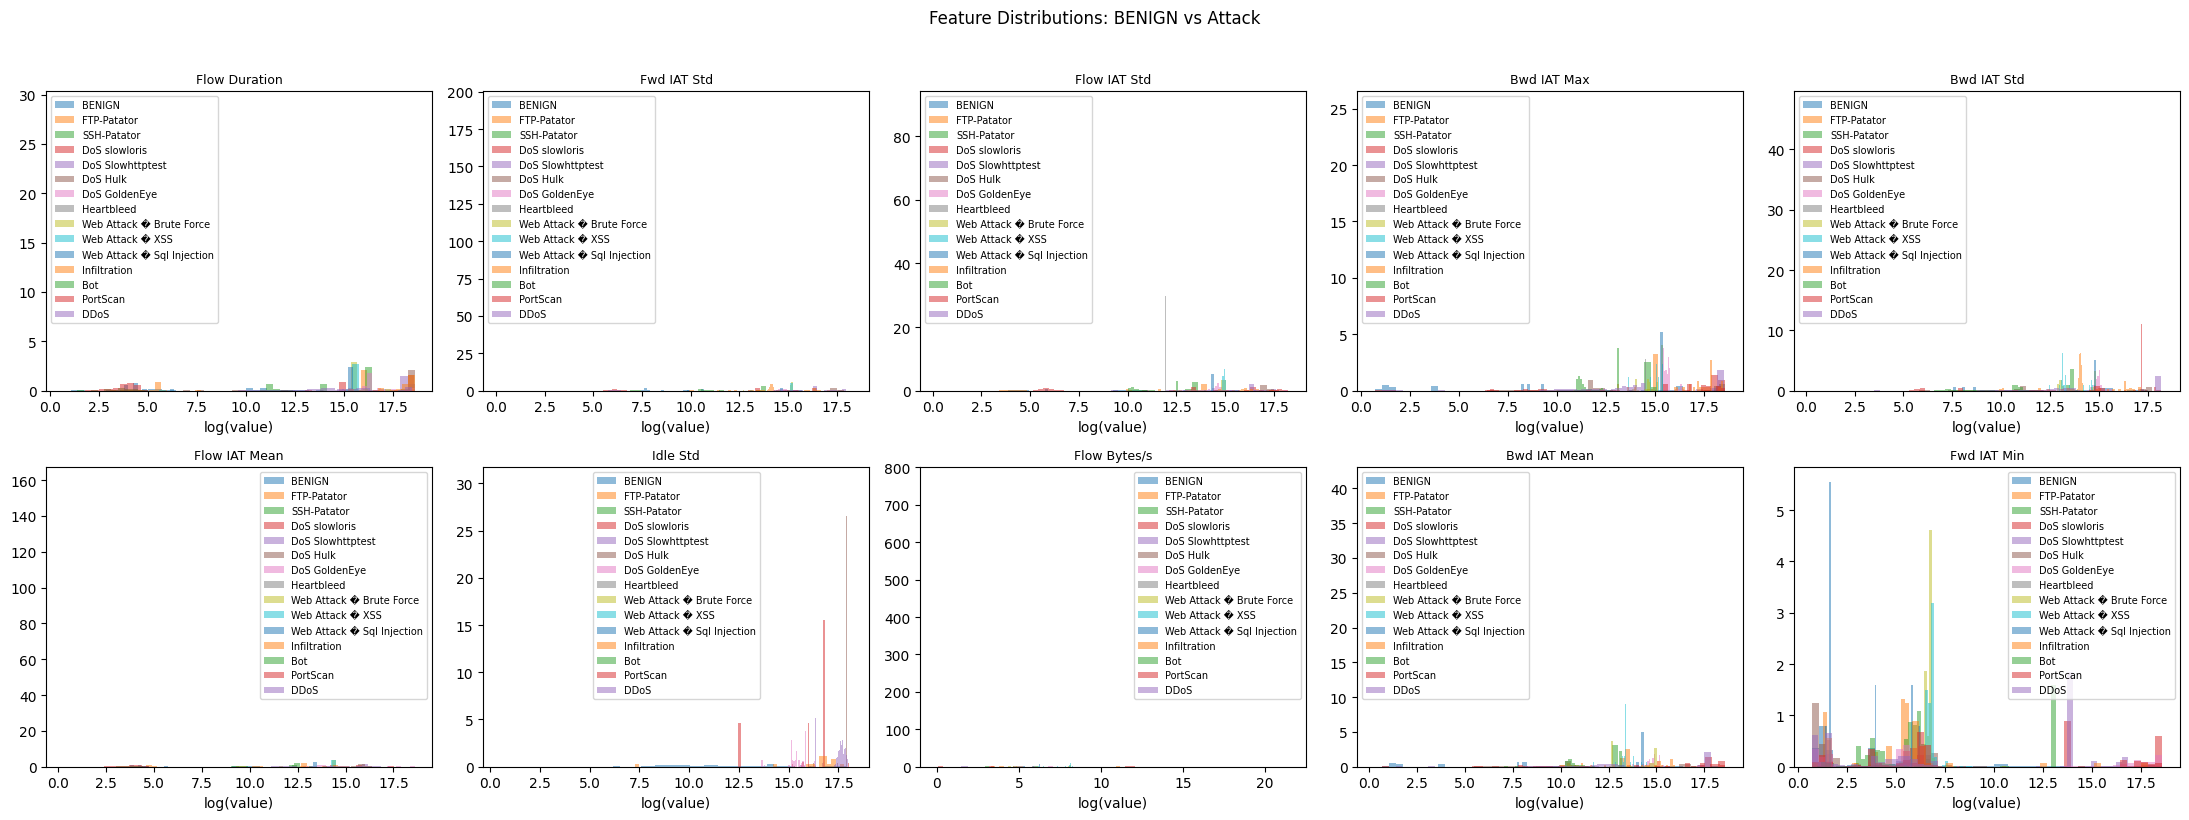

In [36]:
# Identify which features are most useful for classification (which features are good a separating classes)
benign = df_reduced[df_reduced['Label'] == 'BENIGN']
attack = df_reduced[df_reduced['Label'] != 'BENIGN']

benign = benign.iloc[:, :-1]
attack = attack.iloc[:, :-1]

diff = (attack.mean() - benign.mean()).abs().sort_values(ascending=False)
print(diff.head(10))

key_features = diff.head(10).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    for label in df_reduced['Label'].unique():
        subset = df_reduced[df_reduced['Label'] == label][feature].dropna()
        subset = subset[subset > 0]  # log scale requires positive values
        axes[i].hist(np.log1p(subset), bins=50, alpha=0.5, label=label, density=True)
    axes[i].set_title(feature, fontsize=9)
    axes[i].set_xlabel('log(value)')
    axes[i].legend(fontsize=7)

plt.suptitle('Feature Distributions: BENIGN vs Attack', y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')

## 9. Attack Type Breakdown

                     Label   count  percentage
                    BENIGN 2095057     83.1109
                  DoS Hulk  172846      6.8568
                      DDoS  128014      5.0783
                  PortScan   90694      3.5978
             DoS GoldenEye   10286      0.4080
               FTP-Patator    5931      0.2353
             DoS slowloris    5385      0.2136
          DoS Slowhttptest    5228      0.2074
               SSH-Patator    3219      0.1277
                       Bot    1948      0.0773
  Web Attack � Brute Force    1470      0.0583
          Web Attack � XSS     652      0.0259
              Infiltration      36      0.0014
Web Attack � Sql Injection      21      0.0008
                Heartbleed      11      0.0004


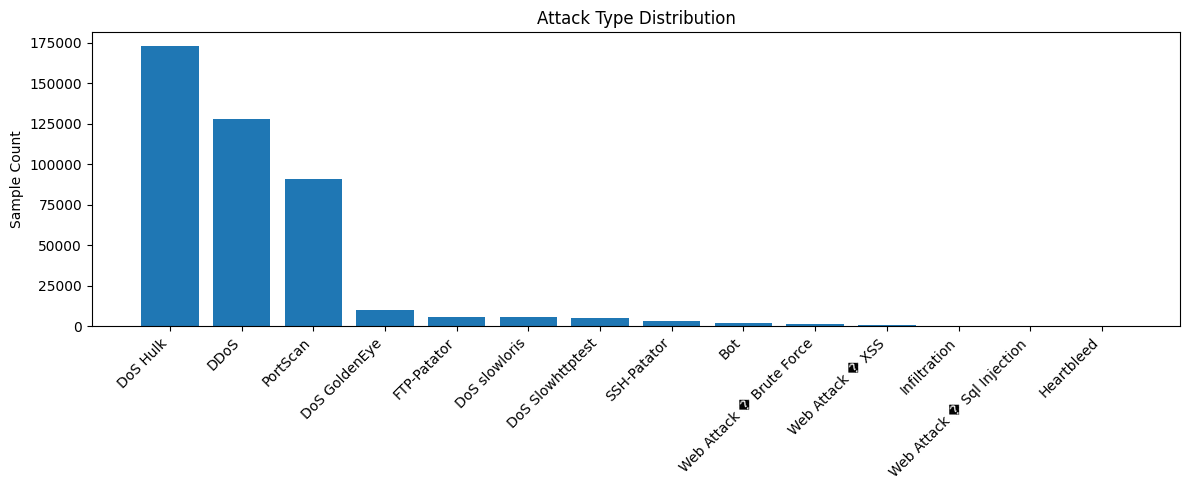

In [40]:
attack_counts = (
    df_complete.groupby('Label')
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)
attack_counts['percentage'] = (attack_counts['count'] / len(df_complete) * 100).round(4)
print(attack_counts.to_string(index=False))



attack_only = attack_counts[attack_counts['Label'] != 'BENIGN']

plt.figure(figsize=(12, 5))
plt.bar(attack_only['Label'], attack_only['count'])
plt.xticks(rotation=45, ha='right')
plt.title('Attack Type Distribution')
plt.ylabel('Sample Count')
plt.tight_layout()
plt.savefig('attack_breakdown.png', dpi=150, bbox_inches='tight')

In [42]:
print('Label' in df_reduced.columns)
print(df_reduced.shape)

True
(2520798, 39)


In [43]:
# Export to CSV
df_reduced.to_csv('data/df_reduced.csv', index=False)